In [1]:
# Standard library
import gc
import pickle
import random

# Third-party
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import distributions, nn, optim
import scanpy as sc
import anndata as ad
import squidpy as sq
import umap
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import matplotlib.patheffects as path_effects
from sklearn.decomposition import NMF, PCA
from sklearn.cluster import KMeans

# Project / local
import gpzoo
from gpzoo.kernels import NSF_RBF, batched_RBF, batched_MGGP_RBF, batched_Matern32, batched_MGGP_Matern32
from gpzoo.gp import GaussianPrior, SVGP, MGGP_VNNGP, MGGP_WSVGP, VNNGP
from gpzoo.likelihoods import PNMF, NSF2, Hybrid_NSF2, Hybrid_NSF_Exact
from gpzoo.utilities import (
    whitened_KL,
    train_hybrid,
    train_hybrid_batched,
    anndata_to_train_val,
    rescale_spatial_coords,
    add_jitter,
    scanpy_sizefactors,
    init_softplus,
    regularized_nmf,
    dims_autocorr,
    plot_factors,
    init_Lu,
    init_Lu_nsf
)


/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. I

In [2]:
def plot_factors(factors, X, moran_idx=None, ax=None, size=7, alpha=0.8, s=0.1, names=None, vmin=None, vmax=None, cmap='turbo'):
    # If vmin/vmax not provided, infer from percentiles
    if vmin is None:
        vmin = np.percentile(factors, 1)
    if vmax is None:
        vmax = np.percentile(factors, 99)

    if moran_idx is not None:
        factors = factors[moran_idx]
        if names is not None:
            names = names[moran_idx]

    L = len(factors)

    if ax is None:
        fig, ax = plt.subplots(1, 4, figsize=(size*4, size*1), tight_layout=True)

    for i in range(L):
        curr_ax = ax[i]

        curr_ax.scatter(
            X[:, 0], X[:, 1],
            c=factors[i],
            vmin=vmin,
            vmax=vmax,
            alpha=alpha,
            cmap=cmap,
            s=s
        )

        curr_ax.invert_yaxis()

        if names is not None:
            curr_ax.set_title(
                names[i],
                x=0.03, y=0.88,
                fontsize="small",
                color="white",
                ha="left", va="top"
            )

        curr_ax.set_xticks([])
        curr_ax.set_yticks([])
        curr_ax.set_facecolor('xkcd:gray')


In [3]:
adata = sc.read_h5ad("/gladstone/engelhardt/home/lchumpitaz/gitclones/nsf-paper/simulations/bm_sp/data/S1.h5ad")

In [4]:
X = adata.obsm["spatial"]
Y = adata.X.T
V = scanpy_sizefactors(Y.T)

In [5]:
V

array([[1.0827866 ],
       [1.0598365 ],
       [0.6945587 ],
       ...,
       [1.0235426 ],
       [0.61527705],
       [1.0364048 ]], shape=(1296, 1), dtype=float32)

In [6]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [7]:
X = torch.tensor(X).type(torch.float)
Y = torch.tensor(Y).type(torch.float)

In [8]:
def build_nsf_model(Y, L=4):

    D, N = Y.shape
    M = N
    
    kernel = batched_Matern32(sigma=1.0, lengthscale=0.3)
    gp = SVGP(kernel, M=M, jitter=1e-5)

    torch.manual_seed(12)
    Lu_init = init_Lu_nsf(kernel, X, X, K=M, niter=10)
    Lu = Lu_init.expand(L, -1, -1)
    # Lu = torch.eye(M).expand(L, M, M)
    gp.Lu = nn.Parameter(Lu.clone().detach())

    
    mu = torch.squeeze(Lu_init@torch.randn(L, M,1))
    gp.mu = nn.Parameter(mu)
    # gp.mu = nn.Parameter(torch.randn((L, M)).type(torch.float))

    Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)
    gp.Z = nn.Parameter(torch.tensor(X), requires_grad=False)

    model = NSF2(gp, Y, L=L)

    W = torch.randn(D, L) 
    model.W = nn.Parameter(W)
    model.V = nn.Parameter(torch.squeeze(torch.ones_like(torch.tensor(V).type(torch.float)))) 
    # model.V = nn.Parameter(torch.squeeze(torch.tensor(init_softplus(V)).type(torch.float))) 
    
    model.to(device)
    return model

In [9]:
def build_nn_nsf_model(Y, L=4, K=50):
    D, N = Y.shape
    M = N
    
    kernel = batched_Matern32( sigma=1.0, lengthscale=0.3)

    gp = VNNGP(kernel, M=M, jitter=1e-5, K=K)

    torch.manual_seed(0)
    Lu_init = init_Lu_nsf(kernel, X, X[::10], K)
    Lu = Lu_init.expand(L, -1, -1)
    gp.Lu = nn.Parameter(Lu.clone().detach())
    
    
    mu = torch.squeeze(Lu_init@torch.randn(L, K,1))
    gp.mu = nn.Parameter(mu)

    Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)
    gp.Z = nn.Parameter(torch.tensor(X), requires_grad=True)

    model = NSF2(gp, Y, L=L)
    model.prior.K = K


    W = torch.randn(D, L) 
    model.W = nn.Parameter(W)
    model.V = nn.Parameter(torch.squeeze(torch.ones_like(torch.tensor(V).type(torch.float)))) 

    knn_idx = model.prior.calculate_knn(X)[:, :-1]
    model.prior.knn_idx = knn_idx
    knn_idz = model.prior.calculate_knn(model.prior.Z)[:, 1:]
    model.prior.knn_idz = knn_idz
    
    model.to(device)
    return model

In [10]:
def model_grads(model):
    model.prior.kernel.lengthscale.requires_grad = False
    model.prior.kernel.sigma.requires_grad = False
    model.prior.Z.requires_grad=False
    model.prior.mu.requires_grad=True
    model.prior.Lu.requires_grad=True
    model.W.requires_grad=True
    model.V.requires_grad=False

In [11]:
nsf_model = build_nsf_model(Y, L=4)
model_grads(nsf_model)
nsf_optimizer = optim.Adam(filter(lambda p: p.requires_grad, nsf_model.parameters()), lr=2e-2)

/tmp/ipykernel_401813/4113984630.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)
/tmp/ipykernel_401813/4113984630.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gp.Z = nn.Parameter(torch.tensor(X), requires_grad=False)


In [12]:
knn_models = {}
k_numbers = [5, 10, 25, 50, 100]
for k in k_numbers:

    current_model = build_nn_nsf_model(Y, L=4, K=k)
    model_grads(current_model)

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, current_model.parameters()), lr=2e-2)

    knn_models[k] = (current_model, optimizer)

/tmp/ipykernel_401813/2958222346.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)
/tmp/ipykernel_401813/2958222346.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gp.Z = nn.Parameter(torch.tensor(X), requires_grad=True)


In [13]:
def train_svgp_batched_with_tracking(optimizer, model, X, y, device, steps=200, x_batch_size=1000, y_batch_size=1000, E=20, **kwargs):
    losses = []

    means = []
    scales = []
    idxs = []

    N = len(X)
    J = len(Y)

    for it in tqdm(range(steps)):

        # Sampling indices for minibatching
        idx = torch.multinomial(torch.ones(N), num_samples=x_batch_size, replacement=False)
        idy = torch.multinomial(torch.ones(J), num_samples=y_batch_size, replacement=False)

        X_batch = X[idx]
        y_batch = y[idy][:, idx]

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        optimizer.zero_grad()
        

        # pY, qF, qZ, _ = model.forward_batched(X_batch.squeeze(), idx=idx, groupsX=groupsX_batch, idy=idy)
        pY, qF, qZ, _ = model.forward_batched_train(X_batch.squeeze(), idx=idx, idy=idy)
        


        logpY = y_batch*torch.log(pY.rate) - pY.rate

        L1 = (logpY).mean(axis=0).sum()
        # L1 = (L1 * N) / batch_size
        L2 = torch.sum(model.prior.kl_divergence(qZ))
        

        log_prob = L1 - L2
        loss = -log_prob

        loss.backward()
        optimizer.step()
        losses.append(loss.item())


        # Only track these every few steps to avoid memory overload
        if (it % 10) == 0:
            idxs.append(idx.detach().cpu().numpy())
            means.append(qF.mean.detach().cpu().numpy())  # or torch.exp(qZ.mean) if Poisson-like
            scales.append(qF.scale.detach().cpu().numpy())


        

        # Cleanup
        del pY, qF, qZ, logpY, L1, L2, log_prob, loss

        del X_batch, y_batch

        with torch.no_grad():
            if device.type == 'cuda':
                torch.cuda.empty_cache()

        gc.collect()

    return losses, means, scales, idxs

In [14]:
def train_vnngp_batched_with_tracking(optimizer, model, X, y, device, steps=200, x_batch_size=1000, y_batch_size=1000, E=20, **kwargs):
    losses = []

    means = []
    scales = []
    idxs = []

    N = len(X)
    J = len(Y)

    full_knn_idx = model.prior.calculate_knn(X).clone()[:, :-1]

    for it in tqdm(range(steps)):

        # Sampling indices for minibatching
        idx = torch.multinomial(torch.ones(N), num_samples=x_batch_size, replacement=False)
        idy = torch.multinomial(torch.ones(J), num_samples=y_batch_size, replacement=False)

        X_batch = X[idx]
        y_batch = y[idy][:, idx]

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        knn_idx = (full_knn_idx[idx]).to(device)
        
        model.prior.knn_idx = knn_idx

        optimizer.zero_grad()
        

        # pY, qF, qZ, _ = model.forward_batched(X_batch.squeeze(), idx=idx, groupsX=groupsX_batch, idy=idy)
        pY, qF, qZ, _ = model.forward_batched(X_batch.squeeze(), idx=idx, idy=idy)
        


        logpY = y_batch*torch.log(pY.rate) - pY.rate

        L1 = (logpY).mean(axis=0).sum()
        # L1 = (L1 * N) / batch_size
        L2 = torch.sum(model.prior.kl_divergence_full(qZ, idx=idx))

        log_prob = L1 - L2
        loss = -log_prob

        loss.backward()
        optimizer.step()
        losses.append(loss.item())


        # Only track these every few steps to avoid memory overload
        if (it % 10) == 0:
            idxs.append(idx.detach().cpu().numpy())
            means.append(qF.mean.detach().cpu().numpy())  # or torch.exp(qZ.mean) if Poisson-like
            scales.append(qF.scale.detach().cpu().numpy())


        

        # Cleanup
        del pY, qF, qZ, logpY, L1, L2, log_prob, loss
        model.prior.knn_idx = None

        del X_batch, y_batch, knn_idx

        with torch.no_grad():
            if device.type == 'cuda':
                torch.cuda.empty_cache()

        gc.collect()

    return losses, means, scales, idxs

In [15]:
Y.shape

torch.Size([200, 1296])

In [ ]:
steps = 5000

In [16]:
losses, means, scales, idxs = train_svgp_batched_with_tracking(nsf_optimizer, nsf_model, X, Y, 
                                                               device, steps=steps, 
                                                               x_batch_size=1296, y_batch_size=200, E=1)

  0%|          | 0/500 [00:00<?, ?it/s]

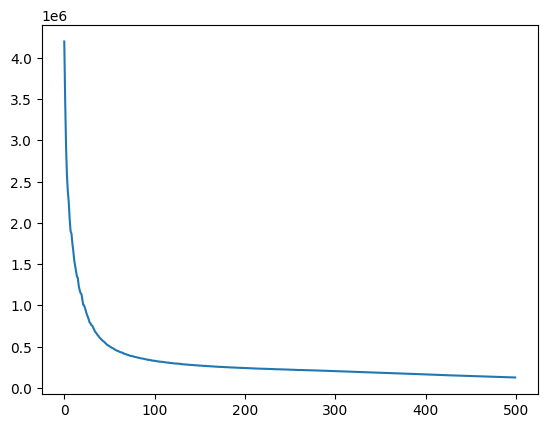

In [17]:
plt.plot(losses)

In [18]:
vmax = np.percentile(np.exp(means[-1]), 95)
vmax

np.float32(1.8762438)

In [19]:
len(means)


50

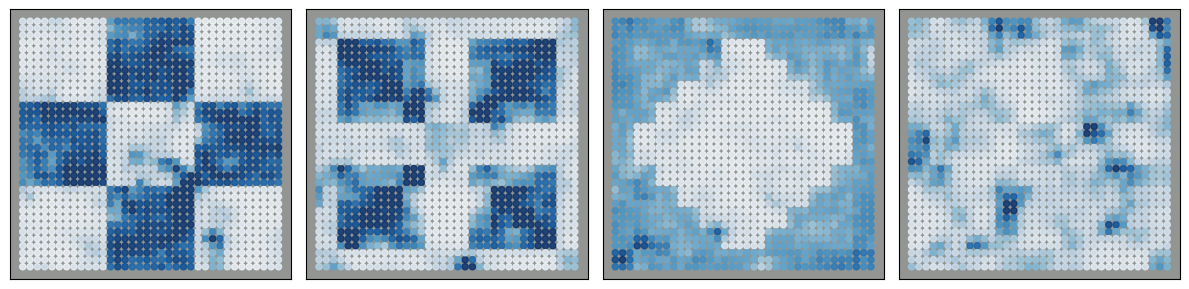

In [20]:
current_idx = -1
plot_factors(np.exp(means[current_idx]), X[idxs[current_idx]], size=3, s=20.0, vmin=0, vmax=vmax, cmap='Blues')

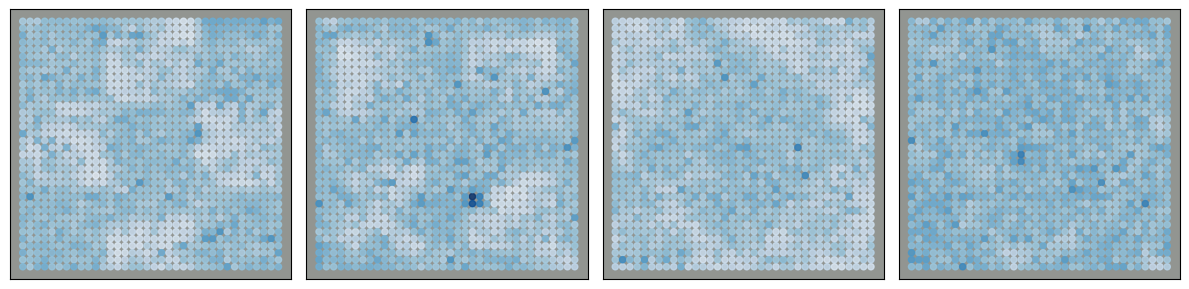

In [21]:
plot_factors(scales[current_idx], X[idxs[current_idx]], size=3, s=20.0, vmin=0, vmax=scales[current_idx].max(), cmap='Blues')

In [22]:
knn_results = {}
for k in k_numbers:

    current_model, current_optimizer=  knn_models[k]

    knn_results[k] = train_vnngp_batched_with_tracking(current_optimizer, current_model, X, Y, 
                                                               device, steps=steps, 
                                                               x_batch_size=1296, y_batch_size=200, E=1)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f0a9a723910>>
Traceback (most recent call last):
  File "/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

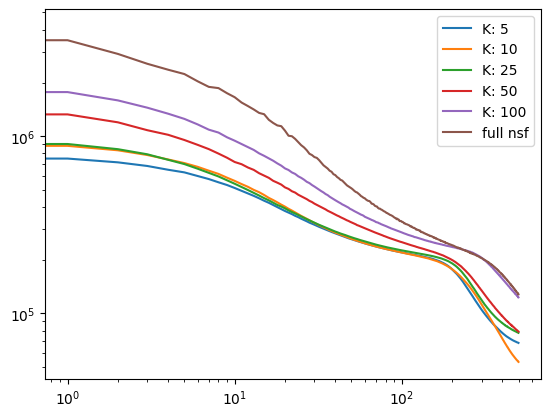

In [25]:
for k in k_numbers:
    current_losses, _, _, _ = knn_results[k]
    plt.loglog(current_losses, label='K: '+str(k))

plt.loglog(losses, label='full nsf')

plt.legend()

/tmp/ipykernel_401813/3786082088.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


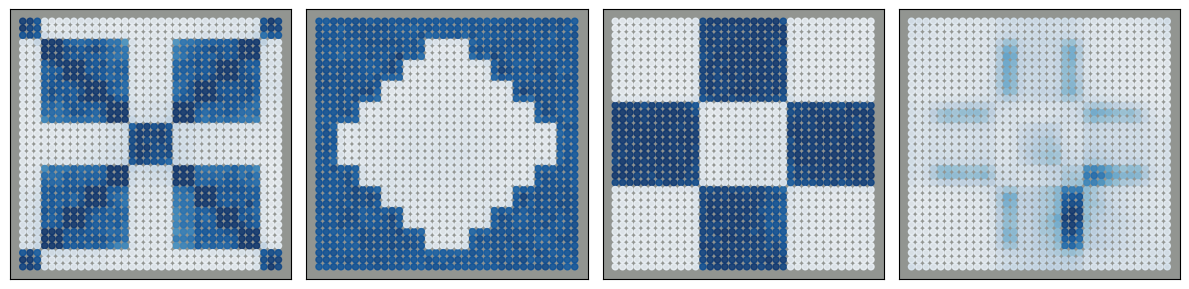

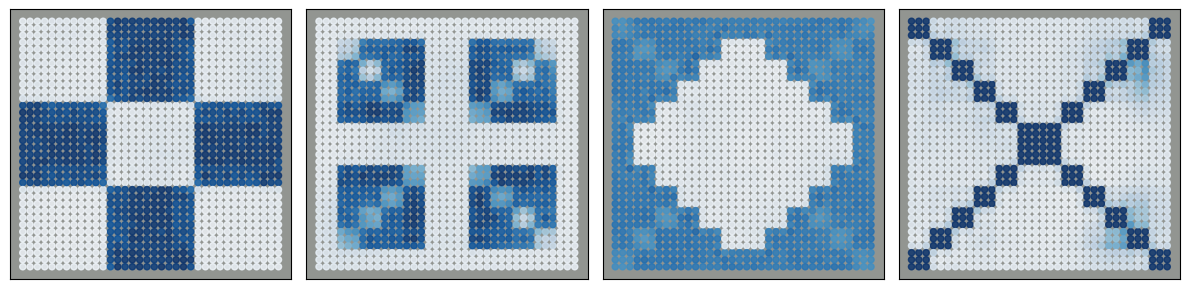

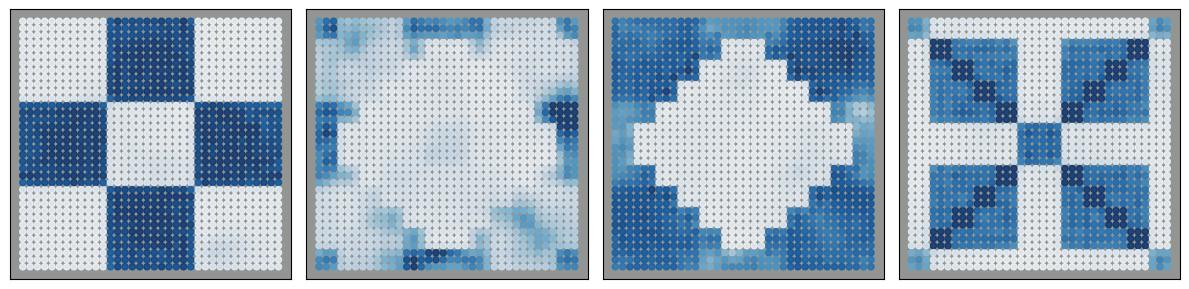

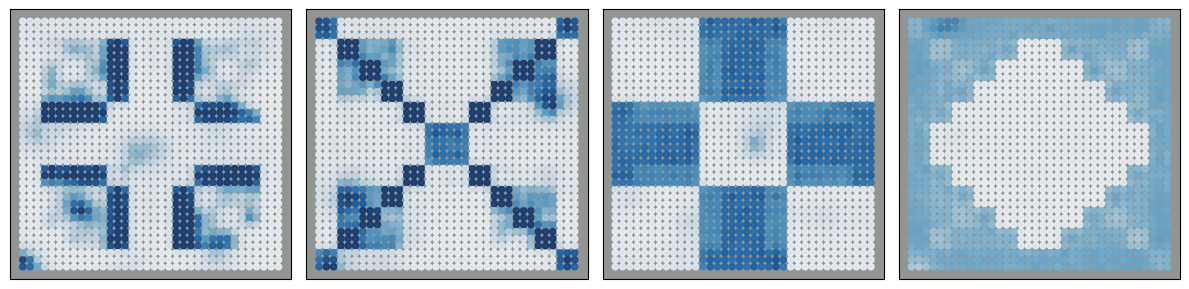

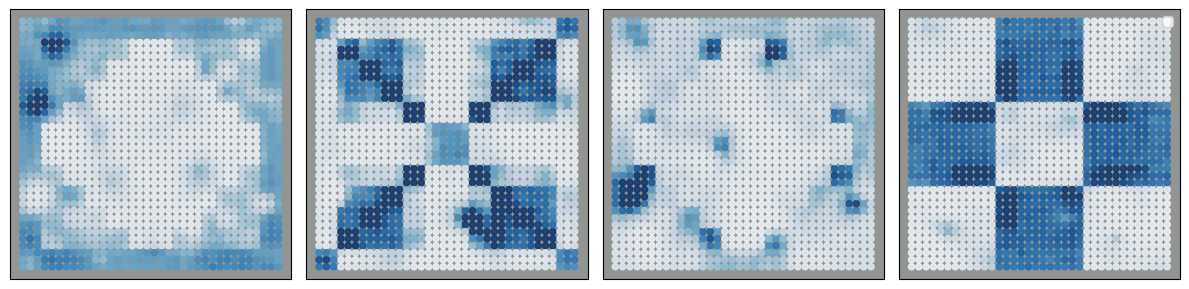

In [26]:
for k in k_numbers:
    _, current_means, _, current_idxs = knn_results[k]

    vmax = np.percentile(np.exp(current_means[-1]), 95)
    
    plot_factors(np.exp(current_means[-1]), X[current_idxs[-1]], size=3, s=20.0, vmin=0, vmax=vmax, cmap='Blues')

plt.legend()